## 1. Imports


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 2. Load Data

In [11]:
df = pd.read_csv(r"C:\Users\Naz\Desktop\Naz\jobs\inv\Code\fabenode-data-report\data\raw\user_48_feb02_14_full_hrv.csv")

## 3. Datetime Preparation

In [12]:
df["start_time"] = pd.to_datetime(df["start_time"])
df["finish_time"] = pd.to_datetime(df["finish_time"])

## 4. Define HRV Columns

In [13]:
hrv_cols = [col for col in df.columns if col.startswith("HRV_")]
hrv_cols

['HRV_MeanNN',
 'HRV_SDNN',
 'HRV_RMSSD',
 'HRV_SDSD',
 'HRV_CVNN',
 'HRV_CVSD',
 'HRV_MedianNN',
 'HRV_MadNN',
 'HRV_MCVNN',
 'HRV_IQRNN',
 'HRV_pNN50',
 'HRV_pNN20',
 'HRV_HTI',
 'HRV_TINN',
 'HRV_LF',
 'HRV_HF',
 'HRV_VHF',
 'HRV_LFHF',
 'HRV_LFn',
 'HRV_HFn',
 'HRV_LnHF',
 'HRV_VLF',
 'HRV_SD1',
 'HRV_SD2',
 'HRV_SD1SD2',
 'HRV_S',
 'HRV_CSI',
 'HRV_CVI',
 'HRV_CSI_Modified',
 'HRV_SampEn',
 'HRV_ApEn']

## 5. Check HRV Availability

In [14]:
df["message"].value_counts(dropna=False).head()

message
ERROR - properties_process-ERROR : There is no best segment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [15]:
df[df["message"] == "SUCCESS"].shape

(735, 56)

In [16]:
df[df["is_ekg_quality"] == True].shape

(1905, 56)

In [23]:
clean_df=df[df["message"] == "SUCCESS"]

In [24]:
clean_df[hrv_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
HRV_MeanNN,735.0,714.396437,84.643895,535.511,657.4860,708.735,757.38000,956.460
HRV_SDNN,735.0,68.760256,60.629153,15.191,37.1680,46.738,74.41650,428.359
HRV_RMSSD,735.0,69.923810,93.910304,7.075,20.5565,29.640,73.56350,582.717
HRV_SDSD,735.0,70.211944,94.384576,7.097,20.6160,29.773,73.74000,585.565
HRV_CVNN,735.0,0.096452,0.084739,0.022,0.0520,0.066,0.10000,0.512
HRV_CVSD,735.0,0.098929,0.133505,0.013,0.0290,0.041,0.10250,0.697
HRV_MedianNN,735.0,710.910287,90.416560,536.133,644.5310,705.078,758.31500,971.680
HRV_MadNN,735.0,49.808367,43.895443,8.687,31.5815,39.258,50.33900,321.423
HRV_MCVNN,735.0,0.071464,0.068078,0.014,0.0450,0.055,0.06700,0.443
HRV_IQRNN,735.0,69.456429,65.061040,13.672,42.6030,54.369,69.82400,463.867


In [18]:
len(hrv_cols)

31

## 6. Select Core HRV Features

In [19]:
selected_hrv = [
    "HRV_MeanNN",   # average interval (baseline)
    "HRV_SDNN",     # overall variability
    "HRV_RMSSD",    # short-term variability
    "HRV_LFHF",     # balance metric
    "HRV_SampEn"    # complexity
]

## 7. Overview of Selected HRV Features

In [25]:
clean_df[selected_hrv].head()

,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_LFHF,HRV_SampEn
130,658.868,264.197,369.547,0.535,1.519
142,689.908,229.821,333.680,0.631,1.162
143,700.439,240.426,332.341,0.423,1.086
148,730.975,310.255,471.470,0.303,1.902
221,888.243,103.247,80.495,0.896,0.876


In [26]:
clean_df[selected_hrv].describe().T

,count,mean,std,min,25%,50%,75%,max
HRV_MeanNN,735.0,714.396437,84.643895,535.511,657.4860,708.735,757.3800,956.460
HRV_SDNN,735.0,68.760256,60.629153,15.191,37.1680,46.738,74.4165,428.359
HRV_RMSSD,735.0,69.923810,93.910304,7.075,20.5565,29.640,73.5635,582.717
HRV_LFHF,735.0,2.307824,1.835533,0.075,0.9465,1.876,3.1775,12.418
HRV_SampEn,735.0,1.211337,0.393385,0.292,0.9565,1.242,1.4500,3.277


#### HRV Feature Summary Interpretation

**HRV_MeanNN**
- Values are relatively stable with moderate spread.
- Mean and median are close, indicating a fairly symmetric distribution.
- Represents a consistent baseline heart rhythm across segments.

**HRV_SDNN**
- Mean is higher than median, indicating right-skewness.
- Large max value compared to 75% suggests presence of extreme outliers.
- Overall variability exists but includes unstable high values.

**HRV_RMSSD**
- Strong right-skew (mean >> median).
- Very high max and std indicate extreme variability and outliers.
- Suggests either physiological spikes or signal artifacts.

**HRV_LFHF**
- Moderately skewed distribution.
- Central values (median ~1.87) are relatively stable.
- Extreme values exist but less pronounced than RMSSD.

**HRV_SampEn**
- Mean and median are close → relatively symmetric distribution.
- Low std → more stable and consistent compared to other HRV features.
- Indicates more reliable behavior across segments.

#### Overall Insight
- Most HRV features are right-skewed with extreme values.
- RMSSD and SDNN show high variability and potential instability.
- SampEn appears to be the most stable feature.
- Median and quartiles are more reliable than mean for interpretation.

## 8. HRV Distributions

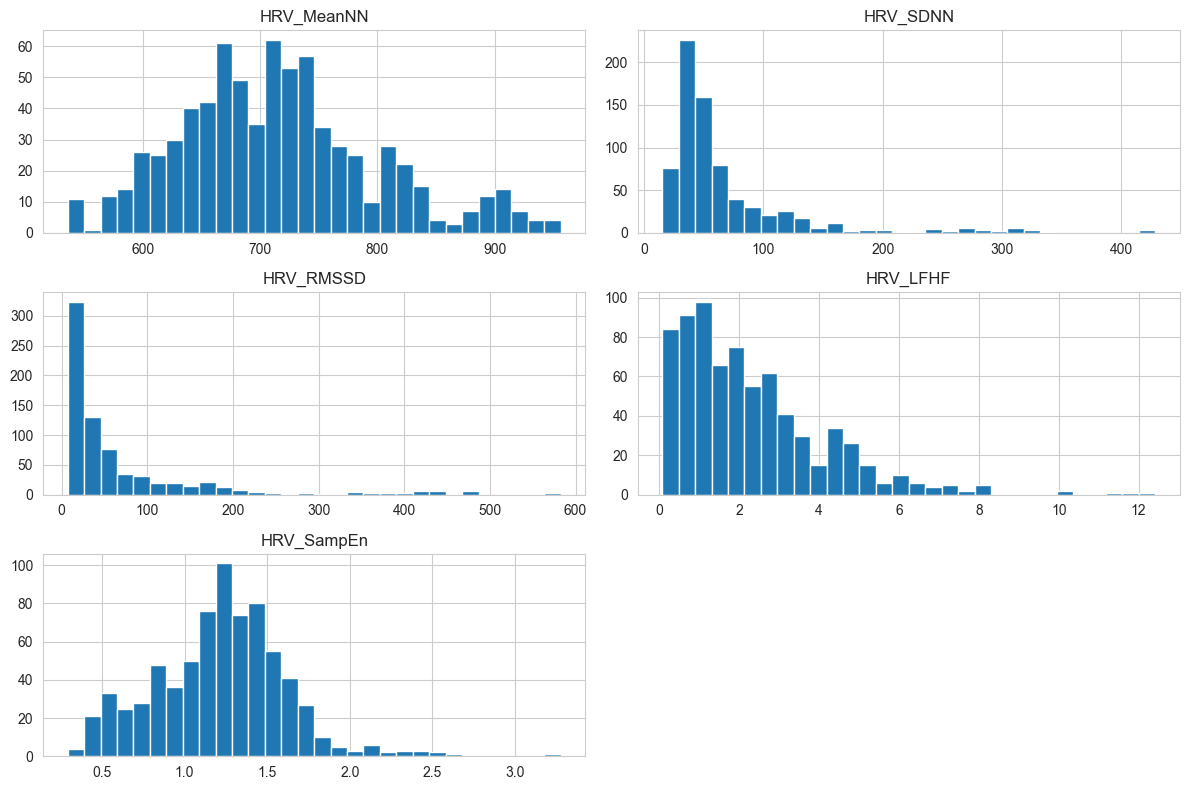

In [27]:
clean_df[selected_hrv].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

## 9.1 RMSSD vs SDNN

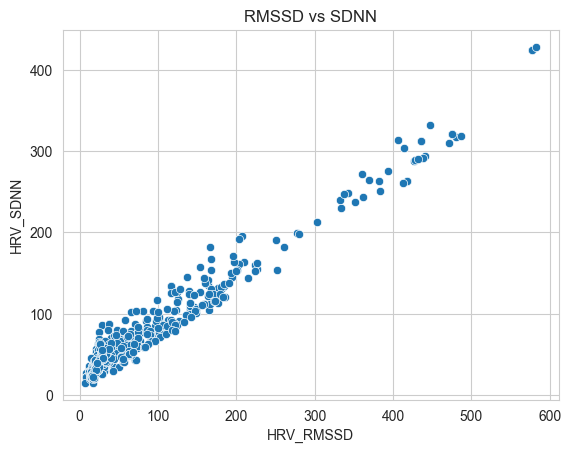

In [28]:
sns.scatterplot(
    x="HRV_RMSSD",
    y="HRV_SDNN",
    data=clean_df
)

plt.title("RMSSD vs SDNN")
plt.xlabel("HRV_RMSSD")
plt.ylabel("HRV_SDNN")
plt.show()

## 9.2 RMSSD vs LFHF

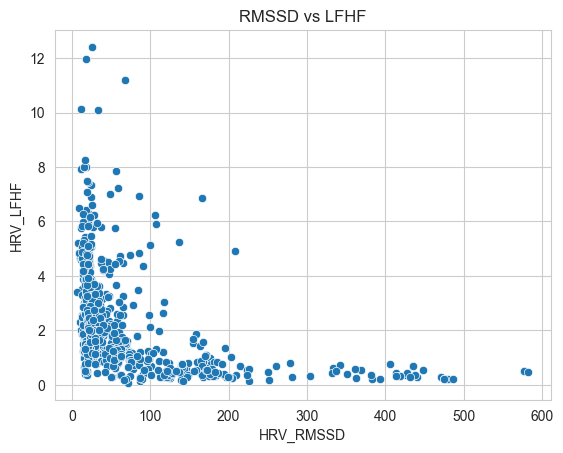

In [29]:
sns.scatterplot(
    x="HRV_RMSSD",
    y="HRV_LFHF",
    data=clean_df
)

plt.title("RMSSD vs LFHF")
plt.show()

## 9.3 Correlation Matrix

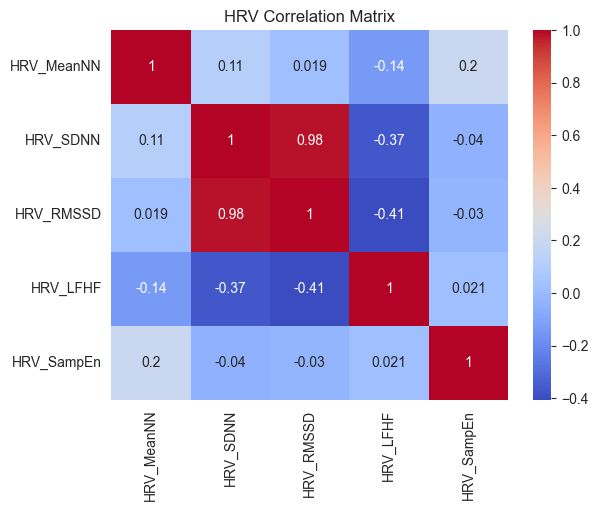

In [30]:
sns.heatmap(
    clean_df[selected_hrv].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("HRV Correlation Matrix")
plt.show()

## 9.4 HRV Relationships Analysis

### RMSSD vs SDNN
- A clear linear relationship is observed between RMSSD and SDNN.
- This indicates a strong positive correlation between short-term and overall variability.
- Since both features are derived from RR interval variability, they capture similar physiological information.
- Therefore, using both features together may introduce redundancy.

### RMSSD vs LFHF
- The relationship between RMSSD and LFHF shows a non-linear "L-shaped" pattern.
- This suggests that LFHF behaves differently from RMSSD and does not scale proportionally with variability.
- RMSSD measures magnitude of variability, while LFHF represents balance between frequency components.
- These features capture different physiological aspects.

### Correlation Structure
- Apart from RMSSD and SDNN, most feature pairs show weak or low correlations.
- This indicates that several HRV features provide independent information.
- Some features (e.g., SampEn) appear to behave more independently and may capture unique signal characteristics.

### Key Insight
- HRV features are not equally informative:
  - RMSSD and SDNN are highly redundant.
  - LFHF and SampEn provide complementary information.
- Feature selection should aim to reduce redundancy while preserving diversity of information.